<a href="https://colab.research.google.com/github/manhtuan09072020-afk/TH_DEEP_LEARNING/blob/main/Buoi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2.Cai dat CNN
2.1 Nap thu vien

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D,Flatten
from keras.models import Sequential
from keras import Input

import matplotlib.pyplot as plt



2.2 doc du lieu MNIST

In [11]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
Y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
Y_test = df_test.iloc[:,0]
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [18]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Convert to numpy array only if it's still a pandas DataFrame
if isinstance(X_train, pd.DataFrame):
    X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)

# Convert to numpy array only if it's still a pandas DataFrame
if isinstance(X_test, pd.DataFrame):
    X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(Y_train)))
print('Classes:', np.unique(Y_train))
print(Y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


2.3 truc quan hoa 10 anh dau tien

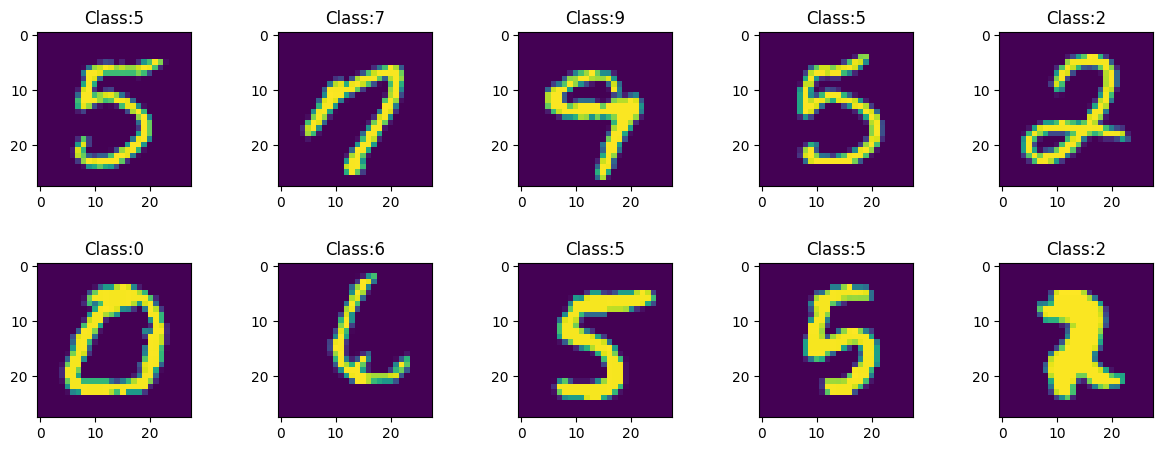

In [19]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(Y_train[i]))
plt.subplots_adjust(hspace = 0.5)
plt.show()

2.4 chuyen gia tri nhan thanh one-hot encording

In [20]:
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)


2.5 xay dung mo hinh CNN

In [21]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units = 10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

2.6 Huan luyen CNN


In [22]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, Y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.1092 - loss: 2.3018 - val_accuracy: 0.1220 - val_loss: 2.3002
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.1111 - loss: 2.3014 - val_accuracy: 0.1220 - val_loss: 2.3004
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.1111 - loss: 2.3013 - val_accuracy: 0.1220 - val_loss: 2.3000
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.1111 - loss: 2.3013 - val_accuracy: 0.1220 - val_loss: 2.3001
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.1111 - loss: 2.3011 - val_accuracy: 0.1220 - val_loss: 2.2994
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.1111 - loss: 2.3012 - val_accuracy: 0.1220 - val_loss: 2.2991
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.1111 - loss: 2.3012 - val_accuracy: 0.1220 - val_loss: 2.2995
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.1111 - loss: 2.3012 - val_

2.7 anh gia mo hinh CNN

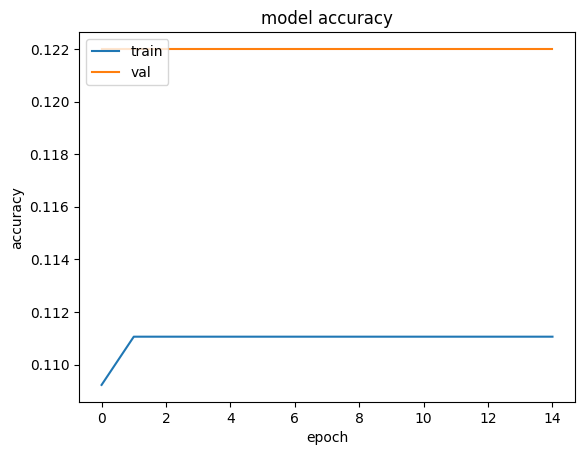

In [23]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

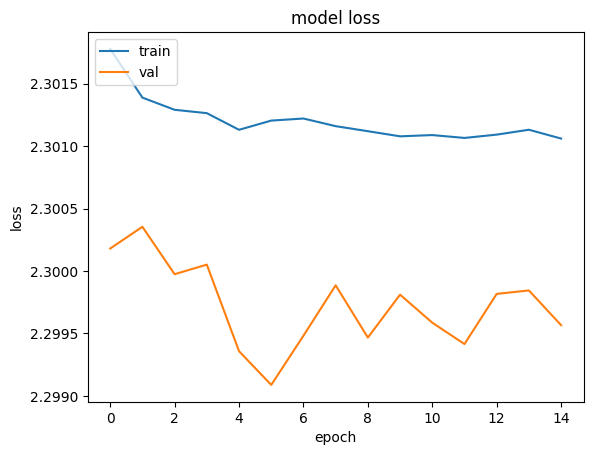

In [24]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

2.8 danh gia mo hinh CNN thu nghiem tren tap test

In [25]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 2.3012802600860596
Test accuracy: 0.1135113537311554


2.9 du bao nhan cho anh su dung CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
[[0.09840683 0.11067835 0.09926204 0.10245252 0.09675313 0.08872224
  0.1026606  0.1052629  0.09512161 0.10067976]]
1 2


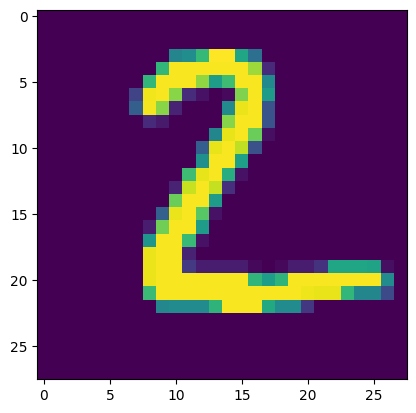

In [26]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(Y_test[0]))
plt.imshow(X_test[0].reshape(28, 28))
plt.show()

2.10 luu tham so mo hinh CNN

In [28]:
model.save_weights('cnn.weights.h5')

2.11 Nap lai mo hinh va tham so

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[0.09840683 0.11067835 0.09926204 0.10245252 0.09675313 0.08872224
  0.1026606  0.1052629  0.09512161 0.10067976]]
1 1


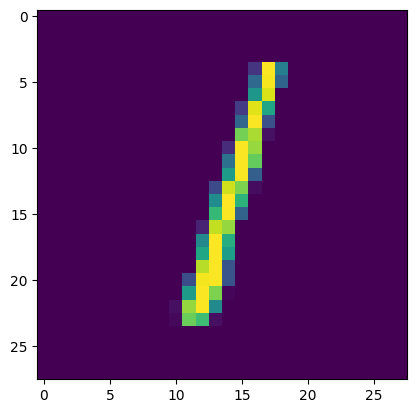

In [29]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units = 10, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(Y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()


3. Bai Tap

1.Viet chuong trinh cai dat CNN de nhan dang anh tren bo dataset CIFAR10 co san trong tensorflow voi cac nhan sau

In [31]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

train_images, test_images = train_images / 255.0, test_images / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.4602 - loss: 1.4977 - val_accuracy: 0.5421 - val_loss: 1.2735
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.5978 - loss: 1.1439 - val_accuracy: 0.6242 - val_loss: 1.0638
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.6504 - loss: 0.9990 - val_accuracy: 0.6593 - val_loss: 0.9849
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.6818 - loss: 0.9172 - val_accuracy: 0.6738 - val_loss: 0.9532
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.7045 - loss: 0.8503 - val_accuracy: 0.6783 - val_loss: 0.9253
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.7209 - loss: 0.7967 - val_accuracy: 0.6941 - val_loss: 0.9047
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 28ms/step - accuracy: 0.7357 - loss: 0.7584 - val_accuracy: 0.6948 - val_loss: 0.9045
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.7498 -

Cau 2: Viet chuong trinh cai dat CNN de nhan dang anh CAT or DOG.

Cau3: Viet chuong trinh cai dat CNN de nhan dang anh Fashion_MNIST.

Cau4: Viet chuong trinh cai dat CNN de nhan dang khuon mat{Nam, Nu}.

Cau 5: Trien khai cau 1-4 tren WEB suwr dung FLASK

In [32]:

model.save('cifar10_model.h5')